<a href="https://colab.research.google.com/github/shivampatle2004/Machine-Learning-/blob/main/Gradient_Boosting_shivam_CS32186.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

. Load the Breast Cancer Dataset



In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as zipnp
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/ml_dataset/BreastCancer.csv" # User-provided path

# Initialize bc for target_names, as it's used in plotting in subsequent cells
bc_temp_for_names = load_breast_cancer()
bc = bc_temp_for_names # Assign to 'bc' for consistency with subsequent cells

try:
    # Load data from the CSV file
    df_bc = pd.read_csv(path)

    # Assuming common structure: 'id' column to drop, 'diagnosis' column as target
    if 'id' in df_bc.columns:
        df_bc = df_bc.drop('id', axis=1)

    if 'diagnosis' in df_bc.columns:
        # Map 'M' (malignant) to 0 and 'B' (benign) to 1 to match sklearn's convention
        y = df_bc['diagnosis'].map({'M': 0, 'B': 1})
        X = df_bc.drop('diagnosis', axis=1)
    else:
        # Fallback if 'diagnosis' column is not found
        print("Warning: 'diagnosis' column not found in CSV. Assuming the last column is target.")
        y = df_bc.iloc[:, -1]
        X = df_bc.iloc[:, :-1]

    # Drop any unnamed columns that might be loaded from CSV artifacts
    # This often happens if a CSV has an extra comma at the end of each row
    X = X.loc[:, ~X.columns.str.contains('^Unnamed')]

except FileNotFoundError:
    print(f"Error: The file at {path} was not found. Please ensure the path is correct and the file exists.")
    print("Falling back to sklearn's built-in Breast Cancer dataset.")
    # If file not found, use the built-in dataset
    bc = load_breast_cancer() # Re-load fully for data as well
    X = pd.DataFrame(bc.data, columns=bc.feature_names)
    y = bc.target
except Exception as e:
    print(f"An error occurred while loading or processing the CSV: {e}")
    print("Falling back to sklearn's built-in Breast Cancer dataset.")
    # If any other error, use the built-in dataset
    bc = load_breast_cancer() # Re-load fully for data as well
    X = pd.DataFrame(bc.data, columns=bc.feature_names)
    y = bc.target

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Target names:", bc.target_names) # Use bc.target_names which was initialized from load_breast_cancer()
display(X.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Features (X) shape: (569, 30)
Target (y) shape: (569,)
Target names: ['malignant' 'benign']


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2. Gradient Boosting with 70/30 Train-Test Split

First, we'll split the data into 70% training and 30% testing sets, train a `GradientBoostingClassifier`, and evaluate its performance.

--- Results for 70/30 Split ---
Accuracy: 0.9474

Confusion Matrix:
 [[ 58   6]
 [  3 104]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        64
           1       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



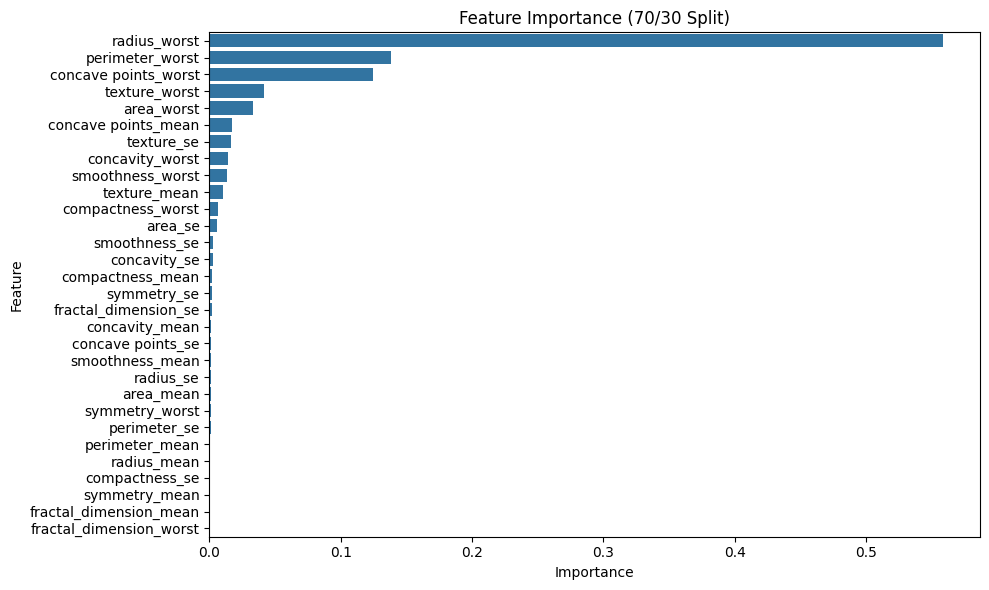

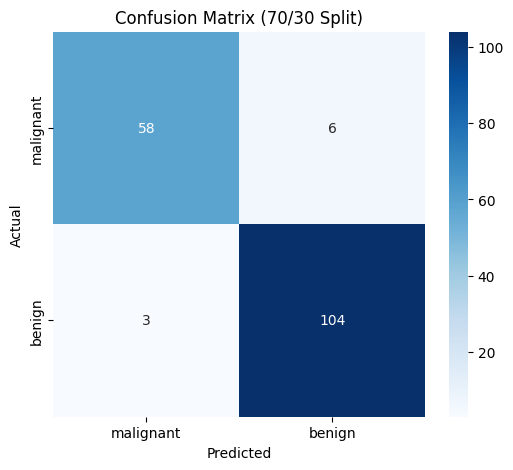

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 70/30 Split
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize and train Gradient Boosting Classifier
gbc_70 = GradientBoostingClassifier(random_state=42)
gbc_70.fit(X_train_70, y_train_70)

# Make predictions
y_pred_70 = gbc_70.predict(X_test_70)

# Evaluate the model
accuracy_70 = accuracy_score(y_test_70, y_pred_70)
cm_70 = confusion_matrix(y_test_70, y_pred_70)
report_70 = classification_report(y_test_70, y_pred_70)

print(f"--- Results for 70/30 Split ---")
print(f"Accuracy: {accuracy_70:.4f}")
print("\nConfusion Matrix:\n", cm_70)
print("\nClassification Report:\n", report_70)

# Feature Importance
feature_importance_70 = pd.Series(gbc_70.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_70.values, y=feature_importance_70.index)
plt.title('Feature Importance (70/30 Split)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_70, annot=True, fmt='d', cmap='Blues', xticklabels=bc.target_names, yticklabels=bc.target_names)
plt.title('Confusion Matrix (70/30 Split)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 3. Gradient Boosting with 80/20 Train-Test Split


--- Results for 80/20 Split ---
Accuracy: 0.9561

Confusion Matrix:
 [[38  4]
 [ 1 71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



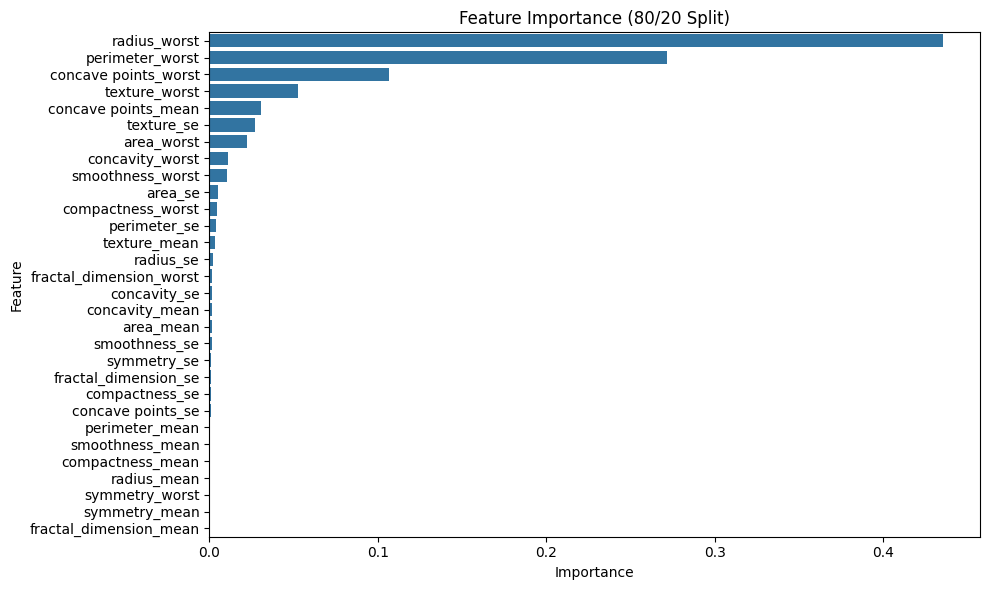

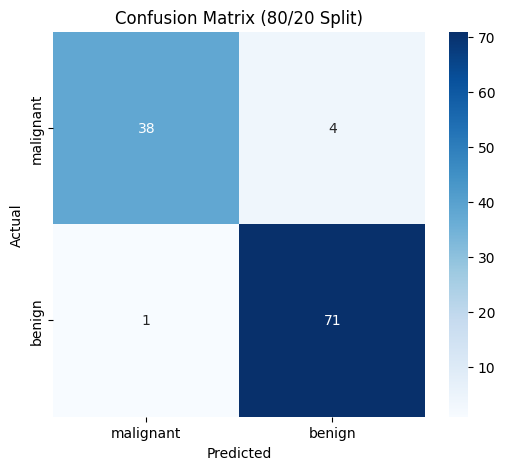

In [ ]:
# 80/20 Split
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Gradient Boosting Classifier
gbc_80 = GradientBoostingClassifier(random_state=42)
gbc_80.fit(X_train_80, y_train_80)

# Make predictions
y_pred_80 = gbc_80.predict(X_test_80)

# Evaluate the model
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
cm_80 = confusion_matrix(y_test_80, y_pred_80)
report_80 = classification_report(y_test_80, y_pred_80)

print(f"--- Results for 80/20 Split ---")
print(f"Accuracy: {accuracy_80:.4f}")
print("\nConfusion Matrix:\n", cm_80)
print("\nClassification Report:\n", report_80)

# Feature Importance
feature_importance_80 = pd.Series(gbc_80.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_80.values, y=feature_importance_80.index)
plt.title('Feature Importance (80/20 Split)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_80, annot=True, fmt='d', cmap='Blues', xticklabels=bc.target_names, yticklabels=bc.target_names)
plt.title('Confusion Matrix (80/20 Split)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 4. Comparison and Conclusion




Comparison of Performance Metrics:


,Split,Accuracy,Precision,Recall,F1-score
0,70/30,0.947368,0.947463,0.947368,0.947101
1,80/20,0.956140,0.956869,0.956140,0.955776


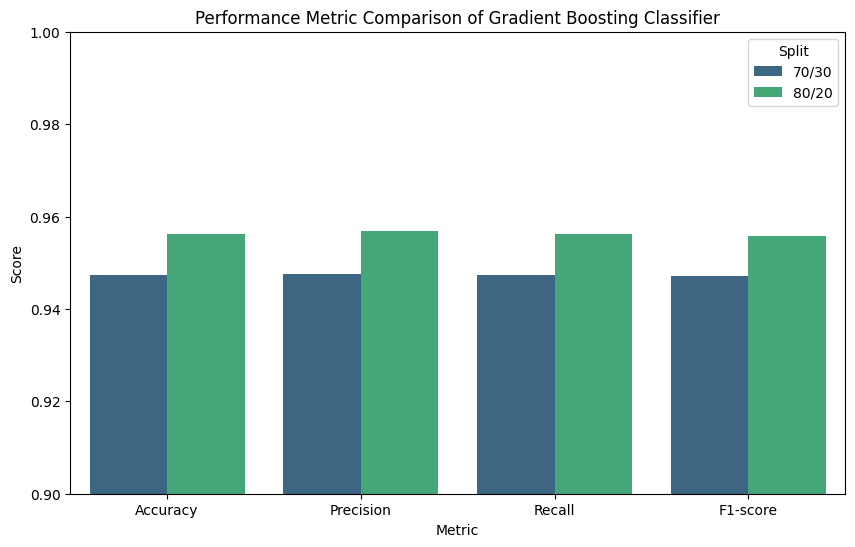

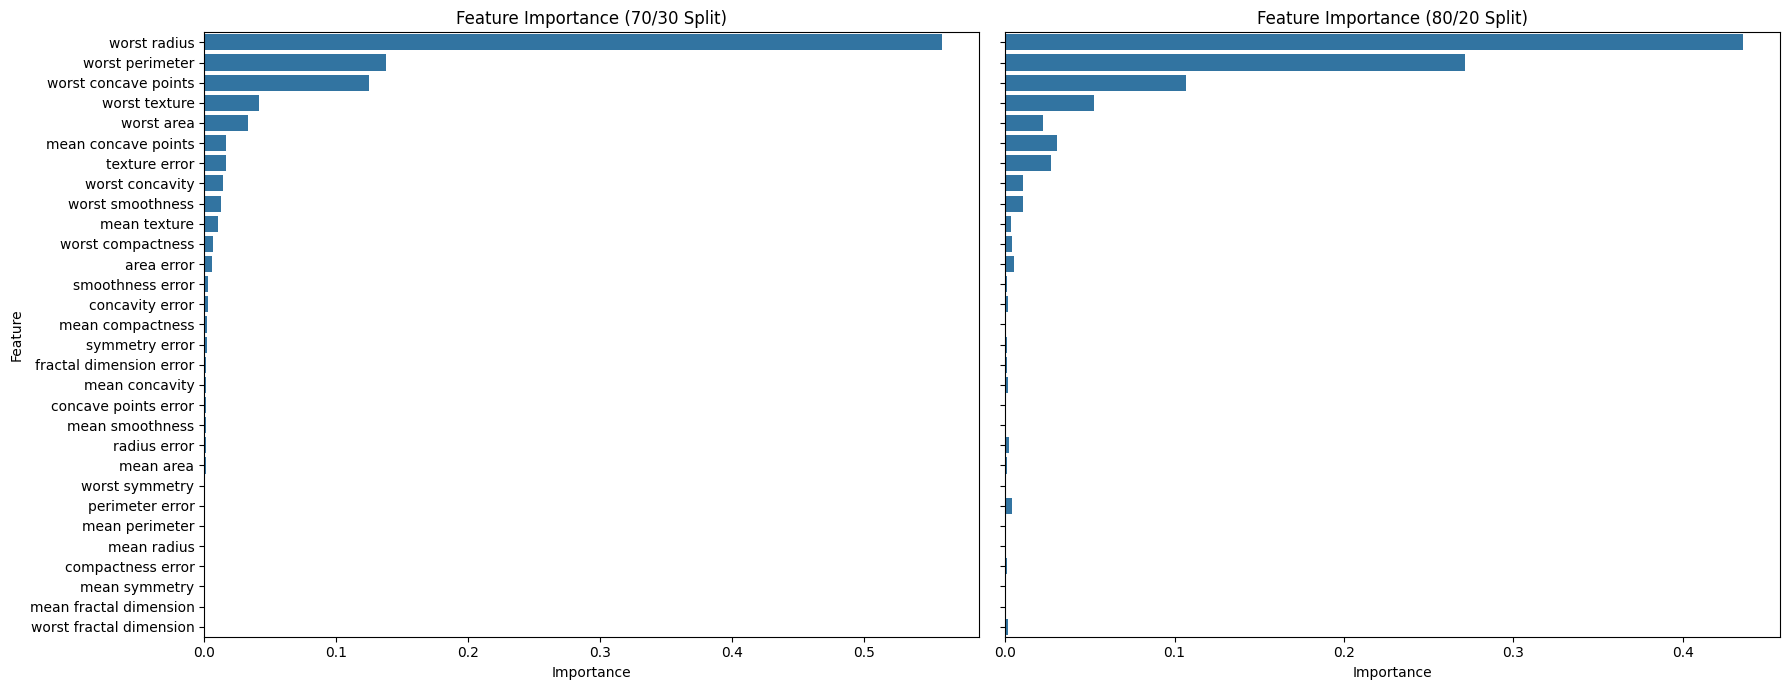

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# --- Start of prepended code to define missing variables ---
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Re-load the dataset to ensure X, y, and bc are defined
bc = load_breast_cancer()
X = pd.DataFrame(bc.data, columns=bc.feature_names)
y = bc.target

# Re-run 70/30 Split logic from cell dc8a09af
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
gbc_70 = GradientBoostingClassifier(random_state=42)
gbc_70.fit(X_train_70, y_train_70)
y_pred_70 = gbc_70.predict(X_test_70)
accuracy_70 = accuracy_score(y_test_70, y_pred_70)
feature_importance_70 = pd.Series(gbc_70.feature_importances_, index=X.columns).sort_values(ascending=False)

# Re-run 80/20 Split logic from cell 9477142c
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
gbc_80 = GradientBoostingClassifier(random_state=42)
gbc_80.fit(X_train_80, y_train_80)
y_pred_80 = gbc_80.predict(X_test_80)
accuracy_80 = accuracy_score(y_test_80, y_pred_80)
feature_importance_80 = pd.Series(gbc_80.feature_importances_, index=X.columns).sort_values(ascending=False)
# --- End of prepended code ---


# Calculate additional metrics for 70/30 split (using weighted average for overall report)
precision_70 = precision_score(y_test_70, y_pred_70, average='weighted')
recall_70 = recall_score(y_test_70, y_pred_70, average='weighted')
f1_70 = f1_score(y_test_70, y_pred_70, average='weighted')

# Calculate additional metrics for 80/20 split (using weighted average for overall report)
precision_80 = precision_score(y_test_80, y_pred_80, average='weighted')
recall_80 = recall_score(y_test_80, y_pred_80, average='weighted')
f1_80 = f1_score(y_test_80, y_pred_80, average='weighted')


metrics_df = pd.DataFrame({
    'Split': ['70/30', '80/20'],
    'Accuracy': [accuracy_70, accuracy_80],
    'Precision': [precision_70, precision_80],
    'Recall': [recall_70, recall_80],
    'F1-score': [f1_70, f1_80]
})

print("\nComparison of Performance Metrics:")
display(metrics_df)

plt.figure(figsize=(10, 6))
metrics_df_melted = metrics_df.melt(id_vars='Split', var_name='Metric', value_name='Score',
                                    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score'])
sns.barplot(x='Metric', y='Score', hue='Split', data=metrics_df_melted, palette='viridis')
plt.title('Performance Metric Comparison of Gradient Boosting Classifier')
plt.ylim(0.9, 1.0)
plt.ylabel('Score')
plt.show()

# Combined Feature Importance Plot (Optional, for direct visual comparison)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.barplot(x=feature_importance_70.values, y=feature_importance_70.index, ax=axes[0])
axes[0].set_title('Feature Importance (70/30 Split)')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

sns.barplot(x=feature_importance_80.values, y=feature_importance_80.index, ax=axes[1])
axes[1].set_title('Feature Importance (80/20 Split)')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

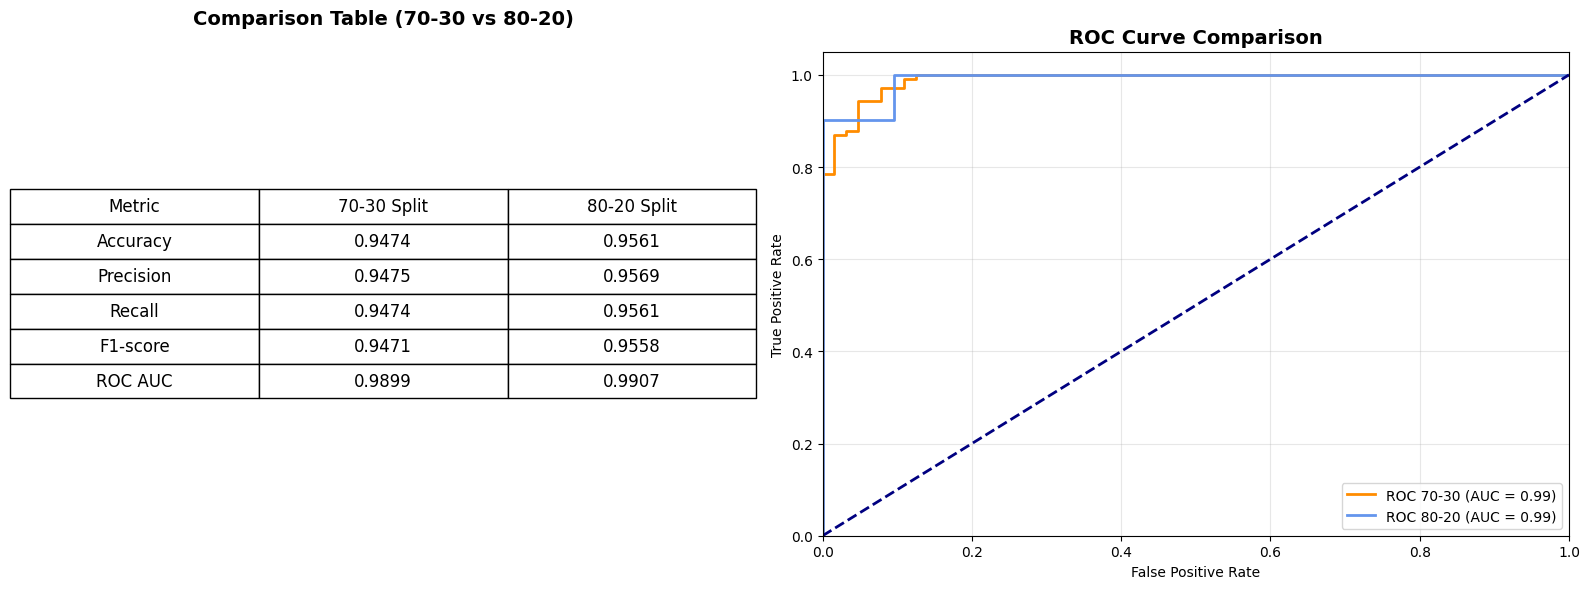

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import pandas as pd

# --- Ensure variables are calculated ---
def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-score': f1_score(y_test, y_pred, average='weighted'),
        'ROC AUC': roc_auc
    }, fpr, tpr, roc_auc

m_70, fpr70, tpr70, auc70 = get_metrics(gbc_70, X_test_70, y_test_70)
m_80, fpr80, tpr80, auc80 = get_metrics(gbc_80, X_test_80, y_test_80)

data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC'],
    '70-30 Split': [round(v, 4) for v in m_70.values()],
    '80-20 Split': [round(v, 4) for v in m_80.values()]
}
df_metrics = pd.DataFrame(data)

# --- Create combined visualization ---
fig, (ax_table, ax_roc) = plt.subplots(1, 2, figsize=(16, 6))

# Left Side: Table
ax_table.axis('tight')
ax_table.axis('off')
table = ax_table.table(cellText=df_metrics.values, colLabels=df_metrics.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
ax_table.set_title('Comparison Table (70-30 vs 80-20)', pad=20, fontsize=14, fontweight='bold')

# Right Side: ROC Graph
ax_roc.plot(fpr70, tpr70, color='darkorange', lw=2, label=f'ROC 70-30 (AUC = {auc70:.2f})')
ax_roc.plot(fpr80, tpr80, color='cornflowerblue', lw=2, label=f'ROC 80-20 (AUC = {auc80:.2f})')
ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.3)

plt.tight_layout()
plt.show()